In [2]:
# 라이브러리 import
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from hmm_model import GaussianHMM2State, smooth_regime

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 데이터 불러오기
adj_price = pd.read_csv('../../00_input/채종원/TRI.csv', index_col='Date', parse_dates=True)
mkt_cap   = pd.read_csv('../../00_input/채종원/시가총액.csv', index_col='Date', parse_dates=True)
div_yield = pd.read_csv('../../00_input/채종원/배당수익률.csv', index_col='Date', parse_dates=True)  
eps_chg   = pd.read_csv('../../00_input/채종원/EPS.csv', index_col='Date', parse_dates=True)  
pbr       = pd.read_csv('../../00_input/채종원/PBR.csv', index_col='Date', parse_dates=True)
factors   = pd.read_csv('../../00_input/Factors.csv', index_col='Date', parse_dates=True)

In [4]:
# 전처리 함수 정의
def make_ff_factors(factors, annual_rf=True):
    """
    factors: DataFrame with columns ['KOSPI','SMB','HML','MOM','RF']
    """
    
    df = factors.copy()

    # 0. resampling
    df = df.resample('ME').last()
    
    # 1. 지수 → 수익률 변환
    ret_cols = ['KOSPI','SMB','HML','MOM']
    df[ret_cols] = df[ret_cols].pct_change()
    
    # 2. 무위험금리 변환 (연율 → 일/월 수익률)
    df['RF'] = df['RF'] / 100  # % → 소수화 (예: 3.5% → 0.035)
    df['RF'] = (1 + df['RF']) ** (1/12) - 1
    
    # 4. 컬럼 정리
    df = df[['KOSPI','SMB','HML','MOM','RF']].dropna()
    
    return df

In [5]:
factors_monthly = make_ff_factors(factors)[:-1]

In [6]:
# 1) 월말 기준으로 리샘플링
monthly_price   = adj_price.resample('ME').last()
monthly_returns = monthly_price.pct_change(fill_method=None)
monthly_mkt_cap = mkt_cap.resample('ME').last()
monthly_pbr     = pbr.resample('ME').last()
monthly_div     = div_yield.resample('ME').last()
monthly_eps     = eps_chg.resample('ME').last()

# 2) PBR 0.2 이하 종목 제거 (상방 제한 없음)
monthly_pbr[monthly_pbr <= 0.2] = pd.NA

In [7]:
# 1) 백테스트 기간 월말 날짜 리스트 생성
month_ends = monthly_price.loc['2015-12-31':'2025-12-31'].index 
# 2) 포트폴리오 수익률을 저장할 Series 객체 생성
portfolio_ret = pd.Series(dtype=float)
portfolio_ret[month_ends[0]] = 0.0 

In [8]:
# bull: 상승장, bear: 하락장
# HMM으로 월말 시점의 하락장(bear) 확률 계산 (일별 인덱스 수익률 필요)
# 인덱스 일별 수익률: KOSPI200 등 일별 시계열이어야 함. 월말만 있으면 별도 일별 데이터 로드 필요.
# KOSPI는 Factors에 열로 저장되어 있음 (열 이름은 실제 CSV에 맞게 수정)
kospi_col = 'KOSPI'   # 또는 'KOSPI200', 'kospi' 등 실제 열 이름
index_daily = factors[kospi_col].copy()
index_daily_returns = index_daily.pct_change().dropna()

# 훈련 구간: 백테스트 시작 이전으로 설정 (look-ahead 방지)
train_end = pd.Timestamp('2015-12-31')
index_rets_train = index_daily_returns.loc[index_daily_returns.index <= train_end]

# HMM 피팅 후 전체 구간에 대해 bull 확률 계산
hmm = GaussianHMM2State(n_iter=100, random_state=42)
hmm.fit(index_rets_train.values)
bull_prob_daily = hmm.bull_prob(index_daily_returns.values)
bull_prob_daily = smooth_regime(bull_prob_daily, window=2)
bull_series_daily = pd.Series(bull_prob_daily, index=index_daily_returns.index)

# 월말 bear 확률 (하락장 확률), month_ends와 맞춤
bear_prob_monthly = (1 - bull_series_daily).resample('ME').last()
bear_prob_monthly = bear_prob_monthly.reindex(month_ends).ffill().bfill()

In [9]:
# IC Series 초기화
ic_div_series = pd.Series(dtype=float)
ic_eps_series = pd.Series(dtype=float)
w_div_series = pd.Series(dtype=float)
w_eps_series = pd.Series(dtype=float)

for i in range(0, len(month_ends) - 1):

    start_date = month_ends[i]
    end_date   = month_ends[i + 1]

    # 1) 유니버스 확정 (상위 50%)
    start_mkt_cap  = monthly_mkt_cap.loc[start_date].dropna()
    breakpoint_val = start_mkt_cap.quantile(0.5)
    large_cap_univ = start_mkt_cap[start_mkt_cap > breakpoint_val].index

    # 2) PBR 필터링
    pbr_filtered = monthly_pbr.loc[start_date, large_cap_univ].dropna()

    # 3) 팩터 데이터 추출
    div_filtered = monthly_div.loc[start_date, pbr_filtered.index].dropna()
    eps_filtered = monthly_eps.loc[start_date, pbr_filtered.index].dropna()
    common_stocks = div_filtered.index.intersection(eps_filtered.index)

    # 4) 당월 IC 계산 (미래 수익률 사용 → 사전 계산용)
    ret_f  = monthly_returns.loc[end_date, common_stocks].dropna()
    common_ic = common_stocks.intersection(ret_f.index)
    if len(common_ic) >= 20:
        ic_div_series[start_date] = spearmanr(
            div_filtered.loc[common_ic].rank(), ret_f.loc[common_ic]
        )[0]
        ic_eps_series[start_date] = spearmanr(
            eps_filtered.loc[common_ic].rank(), ret_f.loc[common_ic]
        )[0]

    # 5) IC 기반 동적 가중치 계산 (과거 12개월)
    div_rank = div_filtered.loc[common_stocks].rank(ascending=True, pct=True)
    eps_rank = eps_filtered.loc[common_stocks].rank(ascending=True, pct=True)

    past_dates  = month_ends[month_ends < start_date][-12:]
    ic_div_mean = max(ic_div_series.reindex(past_dates).mean(), 0)
    ic_eps_mean = max(ic_eps_series.reindex(past_dates).mean(), 0)

    ic_total = ic_div_mean + ic_eps_mean
    if ic_total > 0:
        w_div = ic_div_mean / ic_total
        w_eps = ic_eps_mean / ic_total
    else:
        w_div, w_eps = 0.4, 0.6

    w_div_series[start_date] = w_div
    w_eps_series[start_date] = w_eps

    final_score = (div_rank * w_div) + (eps_rank * w_eps)


    # 6) 상위 10% 종목 선택
    top_n  = max(10, int(len(common_stocks) * 0.10))
    basket = final_score.nlargest(top_n).index

    # 7) HMM 레짐 확률로 주식 비중 결정: 하락장 확률 < 50% → 전액 주식, ≥ 50% → 현금 비율 = bear 확률
    bear_prob = bear_prob_monthly.loc[start_date] if start_date in bear_prob_monthly.index else 0.5
    if pd.isna(bear_prob):
        bear_prob = 0.5
    if bear_prob < 0.5:
        equity_weight = 1.0
    else:
        equity_weight = bear_prob - 0.5

    basket_ret = monthly_returns.loc[end_date, basket].dropna().mean()
    returns = equity_weight * basket_ret

    # 8) 포트폴리오 수익률 업데이트
    portfolio_ret.loc[end_date] = returns


In [10]:
# 포트폴리오 NAV 계산
portfolio_nav = (1 + portfolio_ret).cumprod()
portfolio_nav

2015-12-31    1.000000
2016-01-31    0.960872
2016-02-29    0.977698
2016-03-31    1.048370
2016-04-30    1.065753
                ...   
2025-08-31    3.065098
2025-09-30    3.110542
2025-10-31    3.214440
2025-11-30    3.227921
2025-12-31    3.238293
Length: 121, dtype: float64

<Axes: >

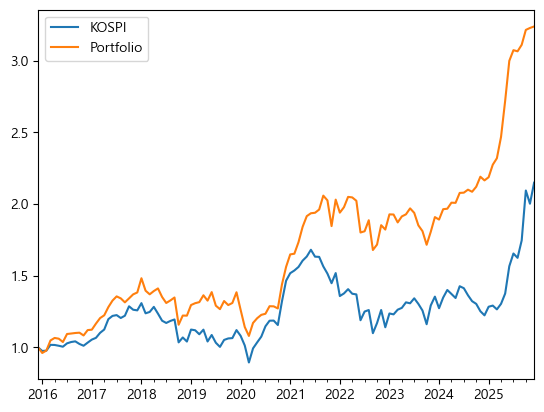

In [11]:
# 1) KOSPI는 factors_monthly에서 이미 월 수익률 → 그대로 cumprod로 NAV 계산
kospi_series = factors_monthly[kospi_col].reindex(portfolio_nav.index)

# 2) 공통 인덱스만 사용 (한쪽만 있는 구간 제외)
common_idx = portfolio_nav.index.intersection(factors_monthly.index)
kospi_series = factors_monthly[kospi_col].loc[common_idx]
portfolio_nav_aligned = portfolio_nav.loc[common_idx]

kospi_nav = (1 + kospi_series).cumprod()

# 3) 포트폴리오 NAV와 초기값 통일
kospi_nav = (kospi_nav / kospi_nav.iloc[0]) * portfolio_nav_aligned.iloc[0]

# 4) 시각화
plot_df = pd.DataFrame({'KOSPI': kospi_nav, 'Portfolio': portfolio_nav_aligned})
plot_df.plot()

In [12]:
portfolio_ret = portfolio_ret[1:]

In [13]:
# CAGR 계산
years = (portfolio_nav.index[-1] - portfolio_nav.index[0]).days / 365.25
cagr  = portfolio_nav.iloc[-1] ** (1 / years) - 1
print(f'CAGR: {cagr:.2%}')

# 연 환산 변동성 계산
volatility = portfolio_ret.std() * np.sqrt(12)
print(f'Annualized Volatility: {volatility:.2%}')

# Sharpe Ratio 계산 (무위험 수익률 연 2% 반영)
risk_free_rate = (1 + 0.02) ** (1 / 12) - 1          
excess_returns = portfolio_ret - risk_free_rate
sharpe_ratio   = excess_returns.mean() / excess_returns.std() * np.sqrt(12)
print(f'Sharpe Ratio: {sharpe_ratio:.2f}')


CAGR: 12.47%
Annualized Volatility: 15.37%
Sharpe Ratio: 0.72


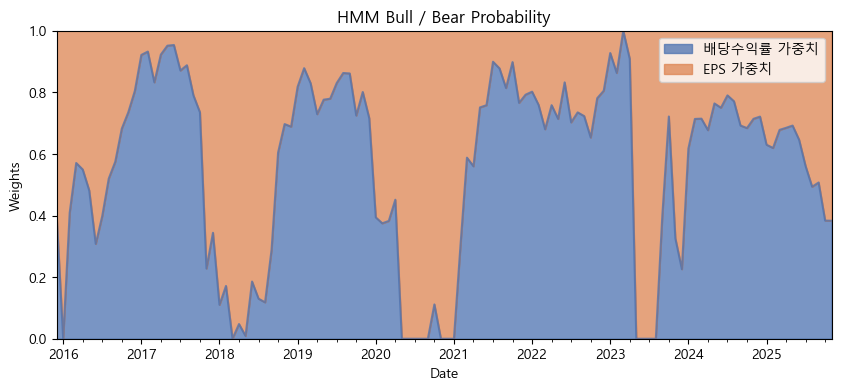

In [22]:
# IC 기반 동적 가중치 시계열 확인 및 시각화
weights_df = pd.DataFrame({
    '배당수익률 가중치': w_div_series,
    'EPS 가중치': w_eps_series
})

ax = weights_df.plot.area(
    figsize=(10, 4),
    stacked=True,
    alpha=0.75,
    color=['#4C72B0', '#DD8452'],
    title='HMM Bull / Bear Probability'
)
ax.set_ylabel('Weights')
ax.set_xlabel('Date')
ax.set_ylim(0, 1)
plt.show()

In [15]:
import statsmodels.api as sm

# 팩터 데이터 불러오기
factors = factors_monthly

# 포트폴리오 수익률을 DataFrame으로 변환
portfolio_df = portfolio_ret.to_frame(name='Return')

# 1. 두 데이터 공통 구간 맞추기
df = pd.concat([portfolio_df, factors], axis=1, join="inner").dropna()

In [16]:
# 2. 종속변수: 포트폴리오 초과수익률
y = df['Return'] - df['RF']

# 3. 독립변수: MKT, SMB, HML, MOM
X = pd.DataFrame({
    "MKT": df['KOSPI'] - df['RF'],
    "SMB": df['SMB'],
    "HML": df['HML'],
    "MOM": df['MOM']
}, index=df.index)

X = sm.add_constant(X, has_constant='add')

# 4. OLS 회귀
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":12})  # Newey-West 표준오차

In [17]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.697
Method:                 Least Squares   F-statistic:                     58.68
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           6.67e-27
Time:                        02:24:15   Log-Likelihood:                 277.61
No. Observations:                 120   AIC:                            -545.2
Df Residuals:                     115   BIC:                            -531.3
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0048      0.002      2.189      0.0

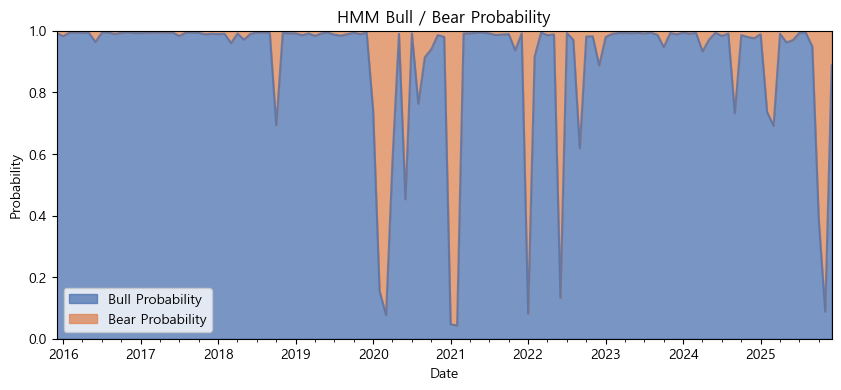

In [18]:
# HMM bull / bear 확률 시계열 시각화
regime_df = pd.DataFrame({
    'Bull Probability': 1 - bear_prob_monthly,
    'Bear Probability': bear_prob_monthly
})

ax = regime_df.plot.area(
    figsize=(10, 4),
    stacked=True,
    alpha=0.75,
    color=['#4C72B0', '#DD8452'],
    title='HMM Bull / Bear Probability'
)
ax.set_ylabel('Probability')
ax.set_xlabel('Date')
ax.set_ylim(0, 1)
plt.show()

## 분위수 검증

In [19]:
# final_score 기준 분위수 검증 + 레짐 분석
q_cut = 5
quantile_cols = [f'Q{i}' for i in range(1, q_cut + 1)]
quantile_ret = pd.DataFrame(index=month_ends[1:], columns=quantile_cols, dtype=float)
quantile_ret_bull = pd.DataFrame(index=month_ends[1:], columns=quantile_cols, dtype=float)
quantile_ret_bear = pd.DataFrame(index=month_ends[1:], columns=quantile_cols, dtype=float)
regime_by_month = pd.Series(index=month_ends[1:], dtype=object)

for i in range(0, len(month_ends) - 1):
    start_date = month_ends[i]
    end_date   = month_ends[i + 1]

    start_mkt_cap  = monthly_mkt_cap.loc[start_date].dropna()
    breakpoint_val = start_mkt_cap.quantile(0.5)
    large_cap_univ = start_mkt_cap[start_mkt_cap > breakpoint_val].index

    pbr_filtered = monthly_pbr.loc[start_date, large_cap_univ].dropna()
    div_filtered = monthly_div.loc[start_date, pbr_filtered.index].dropna()
    eps_filtered = monthly_eps.loc[start_date, pbr_filtered.index].dropna()
    common_stocks = div_filtered.index.intersection(eps_filtered.index)

    if len(common_stocks) < q_cut:
        continue

    div_rank = div_filtered.loc[common_stocks].rank(ascending=True, pct=True)
    eps_rank = eps_filtered.loc[common_stocks].rank(ascending=True, pct=True)

    past_dates  = month_ends[month_ends < start_date][-12:]
    ic_div_mean = max(ic_div_series.reindex(past_dates).mean(), 0)
    ic_eps_mean = max(ic_eps_series.reindex(past_dates).mean(), 0)

    ic_total = ic_div_mean + ic_eps_mean
    if ic_total > 0:
        w_div = ic_div_mean / ic_total
        w_eps = ic_eps_mean / ic_total
    else:
        w_div, w_eps = 0.4, 0.6

    final_score = (div_rank * w_div) + (eps_rank * w_eps)
    final_score = final_score.dropna()

    if len(final_score) < q_cut:
        continue

    quantiles = pd.qcut(final_score.rank(method='first'), q=q_cut, labels=False)
    regime_label = 'Bull' if bear_prob_monthly.loc[start_date] < 0.5 else 'Bear'
    regime_by_month.loc[end_date] = regime_label

    for q in range(q_cut):
        basket = final_score[quantiles == q].index
        basket_ret = monthly_returns.loc[end_date, basket].dropna().mean()
        quantile_ret.loc[end_date, f'Q{q + 1}'] = basket_ret
        if regime_label == 'Bull':
            quantile_ret_bull.loc[end_date, f'Q{q + 1}'] = basket_ret
        else:
            quantile_ret_bear.loc[end_date, f'Q{q + 1}'] = basket_ret

regime_summary = pd.DataFrame({
    'Overall': quantile_ret.mean(),
    'Bull': quantile_ret_bull.mean(),
    'Bear': quantile_ret_bear.mean()
})

regime_summary

,Overall,Bull,Bear
Q1,0.007850,0.005841,0.032624
Q2,0.005508,0.003444,0.030965
Q3,0.006045,0.003748,0.034368
Q4,0.005996,0.003803,0.033048
Q5,0.011294,0.008600,0.044517


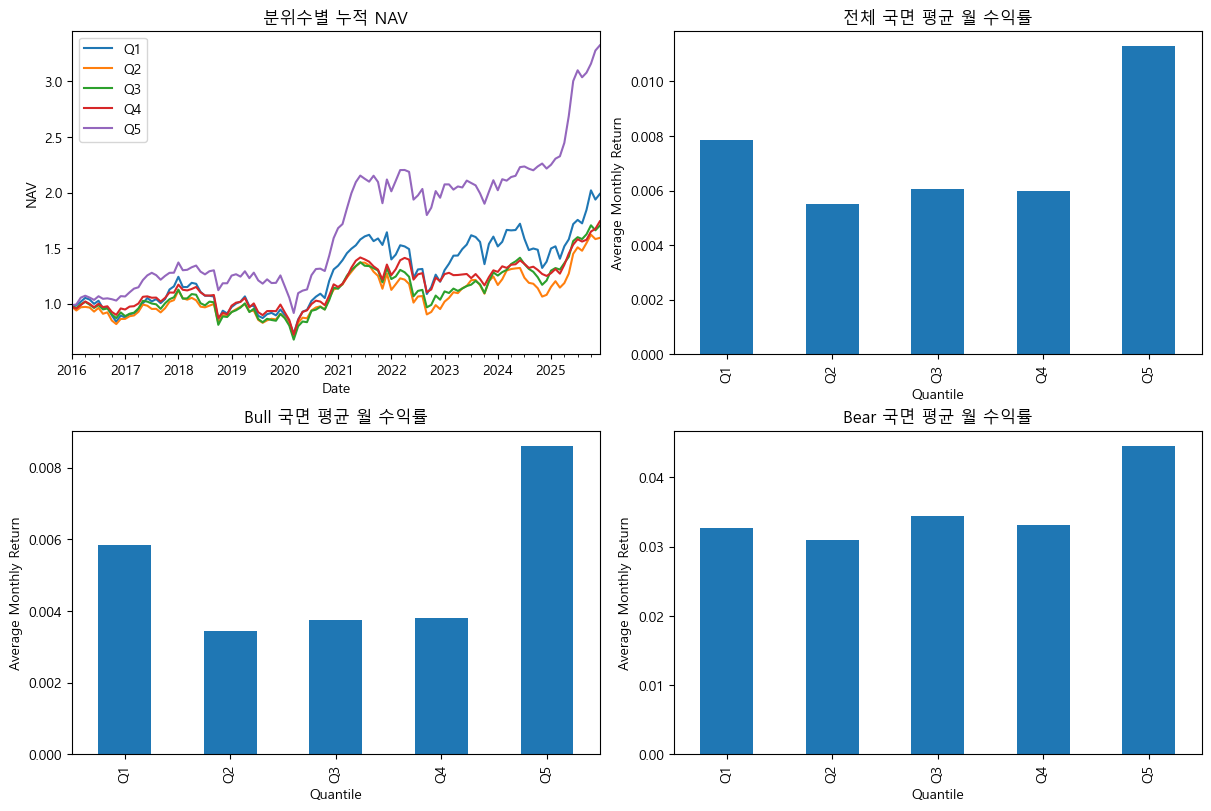

In [20]:
# 분위수별 누적성과 및 레짐별 평균수익률 시각화
quantile_nav = (1 + quantile_ret.fillna(0)).cumprod()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

quantile_nav.plot(ax=axes[0, 0], title='분위수별 누적 NAV')
axes[0, 0].set_ylabel('NAV')
axes[0, 0].set_xlabel('Date')

quantile_ret.mean().plot(kind='bar', ax=axes[0, 1], title='전체 국면 평균 월 수익률')
axes[0, 1].set_ylabel('Average Monthly Return')
axes[0, 1].set_xlabel('Quantile')

quantile_ret_bull.mean().plot(kind='bar', ax=axes[1, 0], title='Bull 국면 평균 월 수익률')
axes[1, 0].set_ylabel('Average Monthly Return')
axes[1, 0].set_xlabel('Quantile')

quantile_ret_bear.mean().plot(kind='bar', ax=axes[1, 1], title='Bear 국면 평균 월 수익률')
axes[1, 1].set_ylabel('Average Monthly Return')
axes[1, 1].set_xlabel('Quantile')

plt.show()